In [1]:
# VIX Index Trend Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

vix = pd.read_csv(r"C:\Users\ivang\Downloads\vix-daily.csv")
vix.tail()

# Open  -> opening value of the index for that day
# Close -> closing value of the index for that day
# High  -> highest value reached during the day
# Low   -> lowest value reached during the day

,DATE,OPEN,HIGH,LOW,CLOSE
9054,11/10/2025,18.58,18.82,17.60,17.60
9055,11/11/2025,17.90,18.01,17.25,17.28
9056,11/12/2025,17.21,18.06,17.10,17.51
9057,11/13/2025,17.61,21.31,17.51,20.00
9058,11/14/2025,21.33,23.03,19.56,19.83


In [2]:
vix.info()
vix.describe()

# The average VIX value is around 19–20, indicating normal or slightly elevated volatility over the long term.
# The relatively high standard deviation shows that the index is highly variable and subject to frequent fluctuations.
# The median is lower than the mean, indicating a right-skewed distribution. 

vix["CLOSE"].skew()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9059 entries, 0 to 9058
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DATE    9059 non-null   object 
 1   OPEN    9059 non-null   float64
 2   HIGH    9059 non-null   float64
 3   LOW     9059 non-null   float64
 4   CLOSE   9059 non-null   float64
dtypes: float64(4), object(1)
memory usage: 354.0+ KB


np.float64(2.1987704449316756)

In [3]:
# New variables

# Intraday volatility
vix['range'] = vix['HIGH'] - vix['LOW']
vix.tail()

# Daily percentage return
vix['ret_close'] = vix['CLOSE'].pct_change()

# Daily logarithmic return
vix['log_ret'] = np.log(vix['CLOSE'] / vix['CLOSE'].shift(1))

# 20-day moving average
vix['ma_20'] = vix['CLOSE'].rolling(20).mean()

# 20-day realized volatility
vix['vol_20'] = vix['CLOSE'].pct_change().rolling(20).std()

vix.tail()

,DATE,OPEN,HIGH,LOW,CLOSE,range,ret_close,log_ret,ma_20,vol_20
9054,11/10/2025,18.58,18.82,17.60,17.60,1.22,-0.077568,-0.080742,18.4875,0.088654
9055,11/11/2025,17.90,18.01,17.25,17.28,0.76,-0.018182,-0.018349,18.3110,0.085913
9056,11/12/2025,17.21,18.06,17.10,17.51,0.96,0.013310,0.013222,18.1545,0.086016
9057,11/13/2025,17.61,21.31,17.51,20.00,3.80,0.142204,0.132960,17.8890,0.075553
9058,11/14/2025,21.33,23.03,19.56,19.83,3.47,-0.008500,-0.008536,17.8415,0.064108


In [4]:
# Sorting
vix_subset = vix[vix['range'] > 5]
vix_subset.head()

,DATE,OPEN,HIGH,LOW,CLOSE,range,ret_close,log_ret,ma_20,vol_20
697,10/05/1992,19.77,25.13,19.37,20.01,5.76,0.124789,0.117596,14.4875,0.059321
1036,02/04/1994,10.71,15.63,10.21,15.25,5.42,0.418605,0.349674,11.3355,0.102727
1652,07/16/1996,20.28,27.05,19.48,20.10,7.57,-0.000497,-0.000497,16.1500,0.068123
1976,10/27/1997,24.91,32.64,24.77,31.12,7.87,0.343116,0.294992,21.6840,0.094561
1977,10/28/1997,45.69,48.64,30.69,31.22,17.95,0.003213,0.003208,22.0995,0.094609


In [5]:
vix_sorted = vix.sort_values('CLOSE', ascending=False)
vix_sorted.head()

,DATE,OPEN,HIGH,LOW,CLOSE,range,ret_close,log_ret,ma_20,vol_20
7606,03/16/2020,57.83,83.56,57.83,82.69,25.73,0.429881,0.357591,38.8500,0.207676
4760,11/20/2008,74.26,81.48,72.76,80.86,8.72,0.088877,0.085147,65.0290,0.103761
4742,10/27/2008,79.13,81.65,71.29,80.06,10.36,0.011753,0.011684,59.3380,0.139135
4741,10/24/2008,67.80,89.53,67.80,79.13,21.73,0.167109,0.154530,57.6710,0.155041
7608,03/18/2020,69.37,85.47,69.37,76.45,16.10,0.007114,0.007089,45.0075,0.211057


In [6]:
# Converting daily data to monthly frequency
vix['DATE'] = pd.to_datetime(vix['DATE'])
vix = vix.set_index('DATE')

vix_monthly = vix.resample('ME').last()
vix_monthly.head()

,OPEN,HIGH,LOW,CLOSE,range,ret_close,log_ret,ma_20,vol_20
DATE,,,,,,,,,
1990-01-31,25.36,25.36,25.36,25.36,0.0,-0.069358,-0.071880,23.9105,0.084395
1990-02-28,21.99,21.99,21.99,21.99,0.0,-0.030851,-0.031336,23.3675,0.048868
1990-03-31,19.73,19.73,19.73,19.73,0.0,0.068797,0.066534,19.9065,0.064205
1990-04-30,19.52,19.52,19.52,19.52,0.0,-0.120324,-0.128202,21.4035,0.087838
1990-05-31,17.37,17.37,17.37,17.37,0.0,-0.004014,-0.004022,18.0200,0.047993


In [7]:
# Realized volatility calculation
vix['rv_10'] = (vix['log_ret']**2).rolling(10).sum()
vix['rv_30'] = (vix['log_ret']**2).rolling(30).sum()

# Volatility ratio calculation
vix['vol_ratio'] = vix['rv_10'] / vix['rv_30']
vix.tail()

# Volatility ratio interpretation:
# ≈ 1   -> recent volatility is similar to past volatility
# < 1   -> recent volatility is lower than longer-term volatility
# > 1   -> recent volatility is increasing, possibly indicating the start of a market stress phase

,OPEN,HIGH,LOW,CLOSE,range,ret_close,log_ret,ma_20,vol_20,rv_10,rv_30,vol_ratio
DATE,,,,,,,,,,,,
2025-11-10,18.58,18.82,17.60,17.60,1.22,-0.077568,-0.080742,18.4875,0.088654,0.030058,0.247194,0.121598
2025-11-11,17.90,18.01,17.25,17.28,0.76,-0.018182,-0.018349,18.3110,0.085913,0.028864,0.247434,0.116655
2025-11-12,17.21,18.06,17.10,17.51,0.96,0.013310,0.013222,18.1545,0.086016,0.028139,0.247608,0.113645
2025-11-13,17.61,21.31,17.51,20.00,3.80,0.142204,0.132960,17.8890,0.075553,0.045818,0.264860,0.172988
2025-11-14,21.33,23.03,19.56,19.83,3.47,-0.008500,-0.008536,17.8415,0.064108,0.044938,0.264931,0.169621


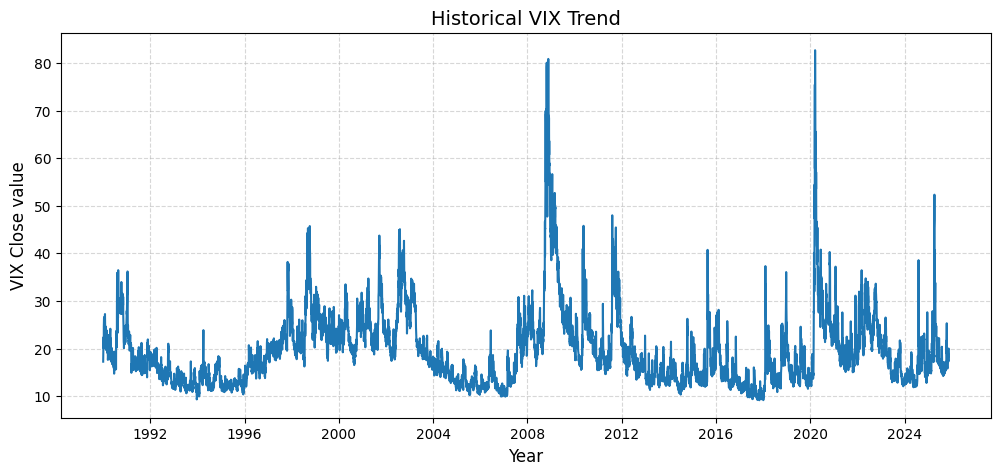

'\n\n# Major VIX spikes correspond to important financial events:\n\n1997  -> Asian financial crisis\n1998  -> Russian default and LTCM collapse risk\n2002  -> Dot-com bubble collapse and corporate scandals\n2008–2009 -> Global financial crisis and Lehman Brothers failure\n2020–2021 -> COVID-19 pandemic and global lockdowns\n2024–2025 -> geopolitical tensions and trade conflicts\n\n'

In [8]:
# Volatility regimes

def volatility_classification(valore_vix):

    if valore_vix < 15:
        return "Low"
    elif valore_vix < 25:
        return "Mid"
    elif valore_vix < 40:
        return "High"
    else:
        return "Very high"

vix["Regime"] = vix["CLOSE"].apply(volatility_classification)

vix[["CLOSE", "Regime"]].head()

# Graphs

# Historical VIX trend
plt.figure(figsize=(12,5))
plt.plot(vix['CLOSE'])
plt.title('Historical VIX Trend', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('VIX Close value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

"""

# Major VIX spikes correspond to important financial events:

1997  -> Asian financial crisis
1998  -> Russian default and LTCM collapse risk
2002  -> Dot-com bubble collapse and corporate scandals
2008–2009 -> Global financial crisis and Lehman Brothers failure
2020–2021 -> COVID-19 pandemic and global lockdowns
2024–2025 -> geopolitical tensions and trade conflicts

"""

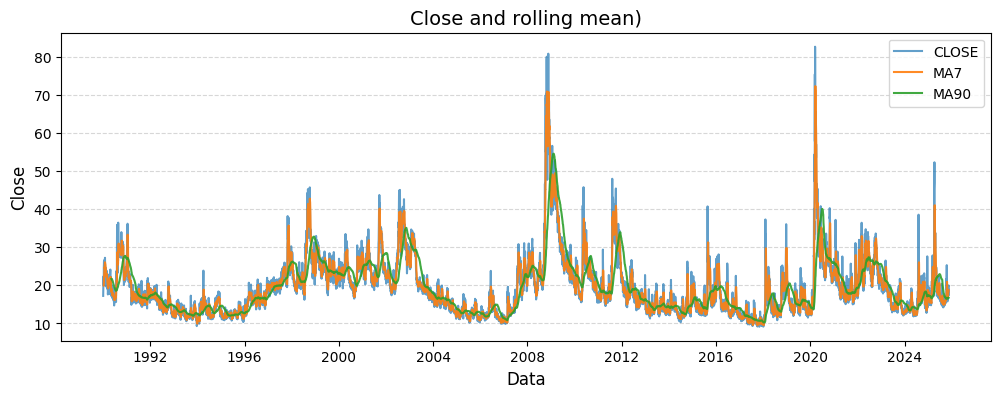

'\n\nThe 7-day moving average highlights short-term fluctuations.\nThe 90-day moving average smooths noise and shows the medium to long-term trend.\nComparing the close series with moving averages helps identify regime shifts and extreme volatility peaks.\n\n'

In [9]:
# Calculating 7-day and 90-day moving averages
vix["MA7"] = vix["CLOSE"].rolling(7).mean()
vix["MA90"] = vix["CLOSE"].rolling(90).mean()

# Graph
plt.figure(figsize=(12,4))
plt.plot(vix["CLOSE"], label="CLOSE", alpha=0.7)
plt.plot(vix["MA7"], label="MA7", alpha=0.9)
plt.plot(vix["MA90"], label="MA90", alpha=0.9)
plt.title("Close and rolling mean)", fontsize=14)
plt.xlabel("Data", fontsize=12)
plt.ylabel("Close", fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

"""

The 7-day moving average highlights short-term fluctuations.
The 90-day moving average smooths noise and shows the medium to long-term trend.
Comparing the close series with moving averages helps identify regime shifts and extreme volatility peaks.

"""

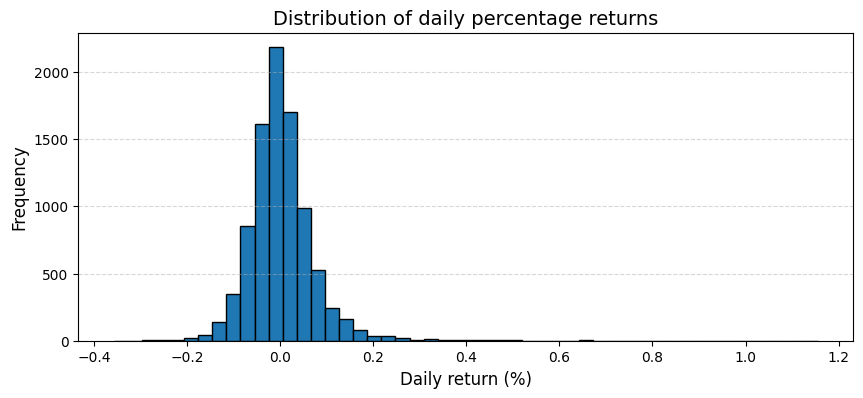

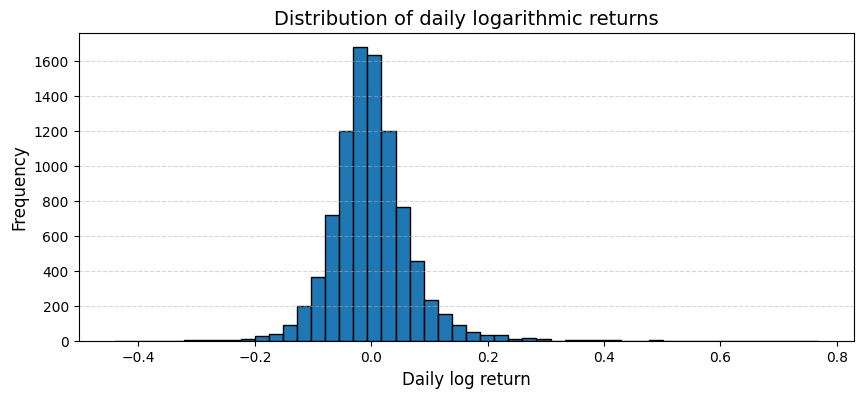

'\n\nThe first histogram shows a right-skewed distribution with a long tail due to extreme movements.\nLog returns produce a more symmetric distribution with reduced distortion from extreme values.\n\n'

In [10]:
# Return distributions

# Distribution of daily percentage returns
plt.figure(figsize=(10,4))
plt.hist(vix['ret_close'].dropna(), bins=50, edgecolor='black')
plt.title('Distribution of daily percentage returns', fontsize=14)
plt.xlabel('Daily return (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Distribution of daily logarithmic returns
plt.figure(figsize=(10,4))
plt.hist(vix['log_ret'].dropna(), bins=50, edgecolor='black')
plt.title('Distribution of daily logarithmic returns', fontsize=14)
plt.xlabel('Daily log return', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

"""

The first histogram shows a right-skewed distribution with a long tail due to extreme movements.
Log returns produce a more symmetric distribution with reduced distortion from extreme values.

"""

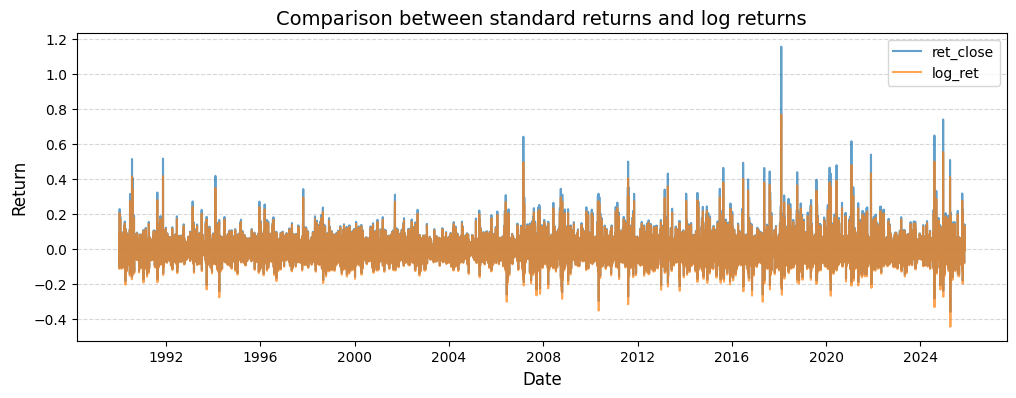

In [11]:
# Comparison between standard returns and log returns
plt.figure(figsize=(12,4))
plt.plot(vix["ret_close"], label="ret_close", alpha=0.7)
plt.plot(vix["log_ret"], label="log_ret", alpha=0.7)
plt.title("Comparison between standard returns and log returns", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Return", fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


Descriptive statistics for returns:
count    9058.000000
mean        0.002381
std         0.071099
min        -0.357539
25%        -0.037302
50%        -0.004073
75%         0.032978
max         1.155979
Name: ret_close, dtype: float64

Descriptive statistics for log returns:
count    9058.000000
mean        0.000015
std         0.067906
min        -0.442449
25%        -0.038015
50%        -0.004081
75%         0.032446
max         0.768245
Name: log_ret, dtype: float64


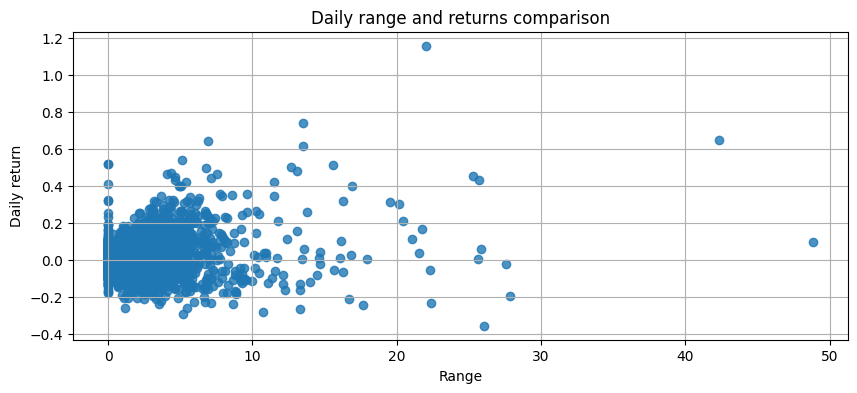

In [12]:
# Descriptive statistics
print("\nDescriptive statistics for returns:")
print(vix["ret_close"].describe())

print("\nDescriptive statistics for log returns:")
print(vix["log_ret"].describe())


# Intraday volatility and extreme values

# Comparing daily range and returns
plt.figure(figsize=(10,4))
plt.scatter(vix['range'], vix['ret_close'], alpha=0.8)
plt.title('Daily range and returns comparison')
plt.xlabel('Range')
plt.ylabel('Daily return')
plt.grid(True)
plt.show()

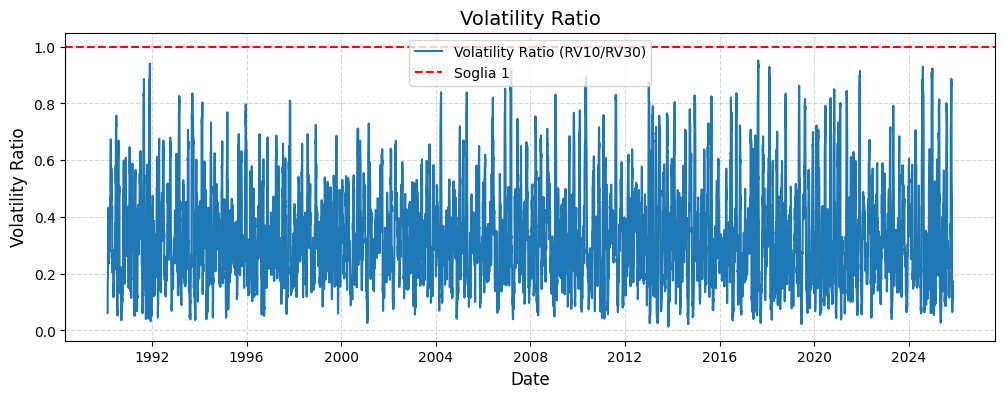

In [13]:
# Volatility ratio

# Comparison between short-term (10-day) and long-term (30-day) volatility
plt.figure(figsize=(12,4))
plt.plot(vix['vol_ratio'], label='Volatility Ratio (RV10/RV30)')
plt.axhline(1, color='red', linestyle='--', label='Soglia 1')
plt.title('Volatility Ratio', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Volatility Ratio', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

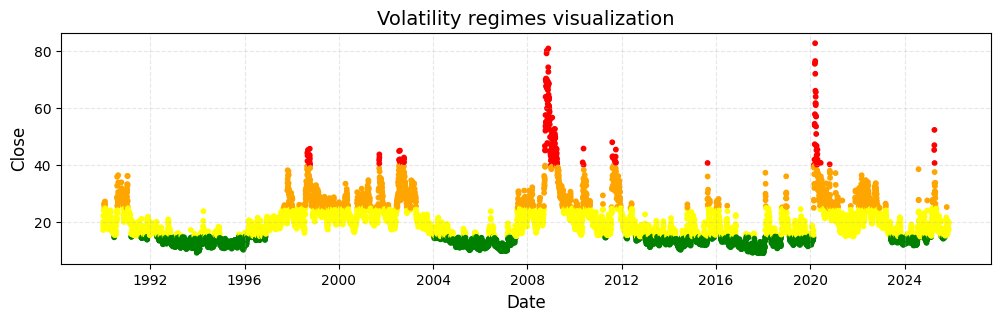

In [14]:
# Volatility regimes visualization

# Visual representation of volatility regimes
plt.figure(figsize=(12,3))
color_map = {'Low':'green','Mid':'yellow','High':'orange','Very high':'red'}
plt.scatter(vix.index, vix['CLOSE'], c=vix['Regime'].map(color_map), s=10)
plt.title('Volatility regimes visualization', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

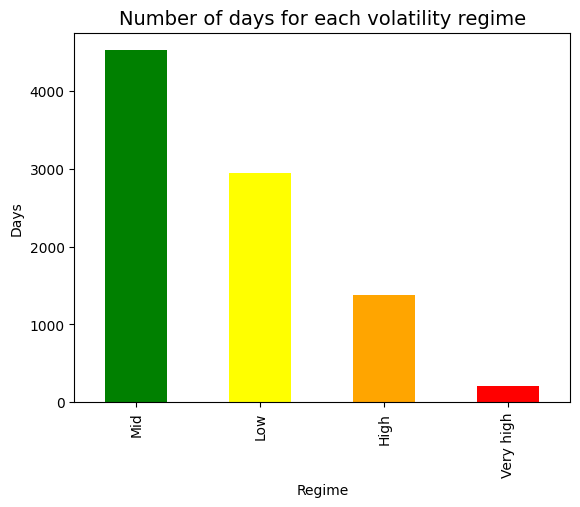

In [15]:
# # Histogram showing the number of days for each volatility regime
vix['Regime'].value_counts().plot(kind='bar', color=['green','yellow','orange','red'])
plt.title('Number of days for each volatility regime', fontsize=14)
plt.ylabel('Days')
plt.show()

In [16]:
# Loading SP500 monthly dataset
sp500 = pd.read_csv(
    r"C:\Users\ivang\Desktop\Python\sp500.csv",
    sep=';',
    decimal=','
)
sp500.columns = sp500.columns.str.strip()
sp500.rename(columns={'Date':'DATE', 'Value':'CLOSE'}, inplace=True)
sp500['DATE'] = pd.to_datetime(sp500['DATE'])
sp500.set_index('DATE', inplace=True)
sp500.index = sp500.index.to_period('M').to_timestamp('M')

print(sp500.head())

            CLOSE
DATE             
1927-12-31  17.66
1928-01-31  17.57
1928-02-29  17.26
1928-03-31  19.28
1928-04-30  19.75


In [17]:
vix_monthly_df = vix_monthly[['CLOSE']].rename(columns={'CLOSE':'VIX'})
sp500_df = sp500[['CLOSE']].rename(columns={'CLOSE':'SP500'})
data = pd.concat([vix_monthly_df, sp500_df], axis=1).dropna()

print(data.head())

              VIX   SP500
DATE                     
1990-01-31  25.36  329.08
1990-02-28  21.99  331.89
1990-03-31  19.73  339.94
1990-04-30  19.52  330.80
1990-05-31  17.37  361.23


In [18]:
data['VIX'] = pd.to_numeric(data['VIX'], errors='coerce')
data['SP500'] = pd.to_numeric(data['SP500'], errors='coerce')
data = data.dropna()

data['VIX_ret'] = np.log(data['VIX'] / data['VIX'].shift(1))
data['SP500_ret'] = np.log(data['SP500'] / data['SP500'].shift(1))
data_returns = data[['VIX_ret', 'SP500_ret']].dropna()

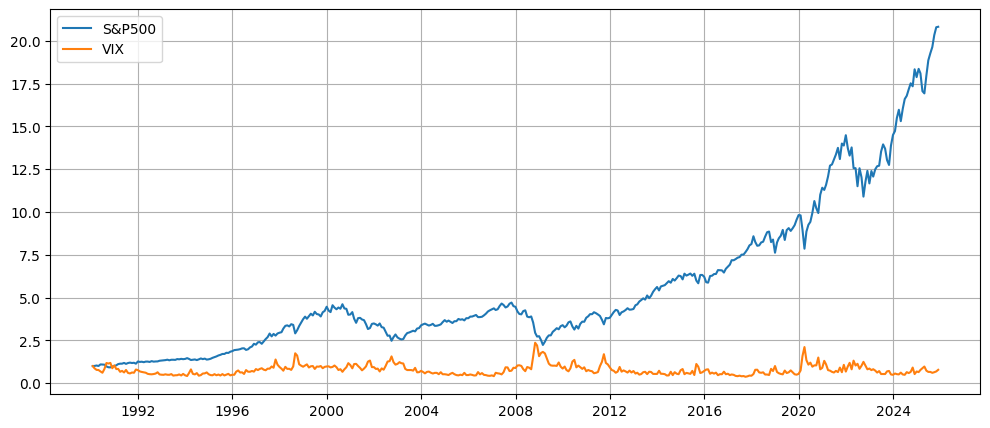

In [19]:
# Graph (normalized values) 
plt.figure(figsize=(12,5))
plt.plot(data['SP500']/data['SP500'].iloc[0], label='S&P500')
plt.plot(data['VIX']/data['VIX'].iloc[0], label='VIX')
plt.legend()
plt.grid(True)
plt.show()

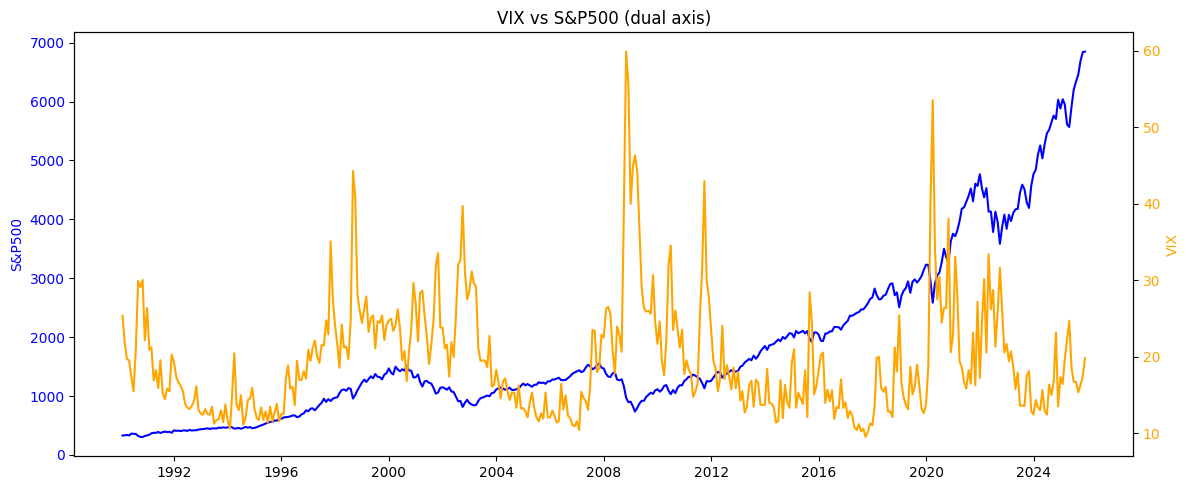

In [20]:
# Graph (dual axis)
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(data['SP500'], color='blue', label='S&P500')
ax1.set_ylabel('S&P500', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(data['VIX'], color='orange', label='VIX')
ax2.set_ylabel('VIX', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('VIX vs S&P500 (dual axis)')
fig.tight_layout()
plt.show()

# In this plot, the S&P500 and the VIX are shown together over time, but on separate vertical axes to preserve
# their natural scales. The S&P500 values are much larger than the VIX, so plotting them on the same axis
# would make the VIX appear almost flat and hide its fluctuations. By assigning the S&P500 to the left
# y-axis and the VIX to the right y-axis, each series retains its original range: the S&P500 rises from
# a few thousand to several hundred thousand, while the VIX fluctuates between roughly 10 and 60. This
# dual-axis approach makes both series fully visible, allowing one to observe the growth of the S&P500
# alongside the oscillations of market volatility captured by the VIX, without distorting either series.

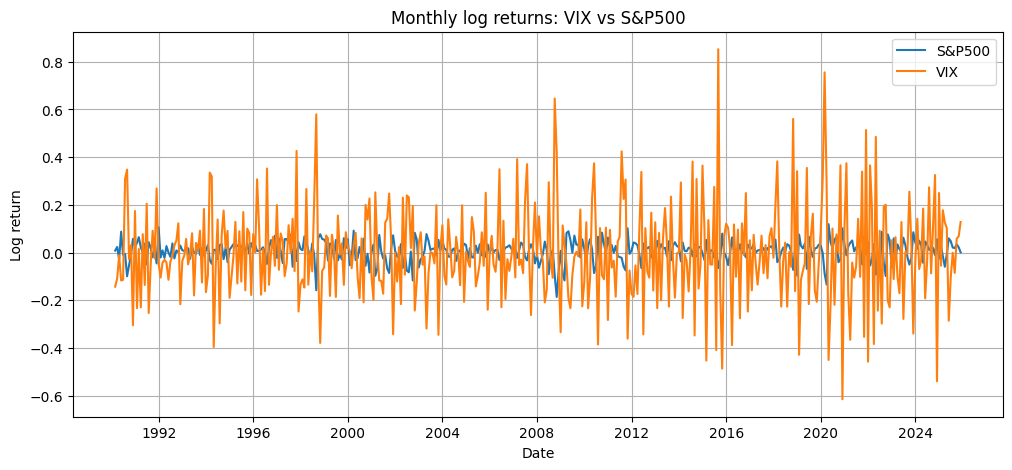

In [21]:
# Monthly log returns graph
plt.figure(figsize=(12,5))
plt.plot(data_returns['SP500_ret'], label='S&P500')
plt.plot(data_returns['VIX_ret'], label='VIX')
plt.title('Monthly log returns: VIX vs S&P500')
plt.xlabel('Date')
plt.ylabel('Log return')
plt.legend()
plt.grid(True)

plt.show()

In [22]:
print(data.head())
print(data.tail())
print(data.describe())
print(data.isna().sum())

              VIX   SP500   VIX_ret  SP500_ret
DATE                                          
1990-01-31  25.36  329.08       NaN        NaN
1990-02-28  21.99  331.89 -0.142585   0.008503
1990-03-31  19.73  339.94 -0.108447   0.023966
1990-04-30  19.52  330.80 -0.010701  -0.027255
1990-05-31  17.37  361.23 -0.116695   0.088001
              VIX    SP500   VIX_ret  SP500_ret
DATE                                           
2025-07-31  16.72  6339.39 -0.000598   0.021435
2025-08-31  15.36  6460.26 -0.084839   0.018887
2025-09-30  16.28  6688.46  0.058171   0.034714
2025-10-31  17.44  6840.20  0.068829   0.022433
2025-11-30  19.83  6849.09  0.128430   0.001299
              VIX        SP500     VIX_ret   SP500_ret
count  431.000000   431.000000  430.000000  430.000000
mean    19.513759  1814.794965   -0.000572    0.007059
std      7.421691  1434.365266    0.199381    0.042702
min      9.510000   304.000000   -0.614279   -0.185636
25%     13.805000   919.230000   -0.117859   -0.017540
50%  

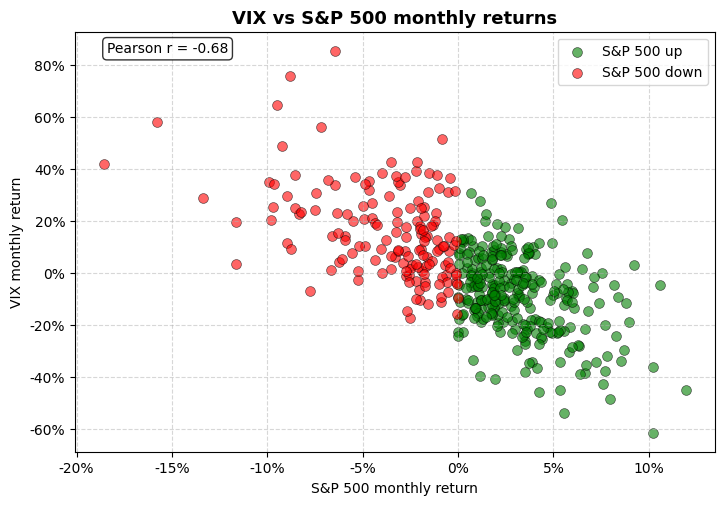

In [23]:
# Scatter plot returns graph
fig, ax = plt.subplots(figsize=(8, 6))

mask_up   = data_returns['SP500_ret'] > 0
mask_down = data_returns['SP500_ret'] <= 0

ax.scatter(data_returns.loc[mask_up,   'SP500_ret'],
           data_returns.loc[mask_up,   'VIX_ret'],
           c='green', s=50, alpha=0.6, edgecolors='k',
           linewidths=0.5, label='S&P 500 up')

ax.scatter(data_returns.loc[mask_down, 'SP500_ret'],
           data_returns.loc[mask_down, 'VIX_ret'],
           c='red',   s=50, alpha=0.6, edgecolors='k',
           linewidths=0.5, label='S&P 500 down')

corr = data_returns['SP500_ret'].corr(data_returns['VIX_ret'])
ax.annotate(f'Pearson r = {corr:.2f}', xy=(0.05, 0.95),
            xycoords='axes fraction', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_title('VIX vs S&P 500 monthly returns',
             fontsize=13, fontweight='bold')
ax.set_xlabel('S&P 500 monthly return')
ax.set_ylabel('VIX monthly return')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))

ax.legend(loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.subplots_adjust(top=0.85, bottom=0.15, left=0.1, right=0.9)
plt.savefig('vix_sp500.png', bbox_inches='tight', pad_inches=0.8)
plt.show()

# The scatter plot shows the relationship between monthly returns of the S&P500 (x-axis) and the VIX
# (y-axis). Points are colored green for positive S&P500 months and red for negative months. The
# pattern illustrates the typical inverse relationship: the VIX tends to rise when the S&P500 falls
# (red points higher) and decline when the S&P500 rises (green points lower). Most points cluster
# near the center, reflecting months with moderate returns for both indices, while the overall
# rightward tilt shows the historical tendency of the stock market to produce more positive
# than negative months.

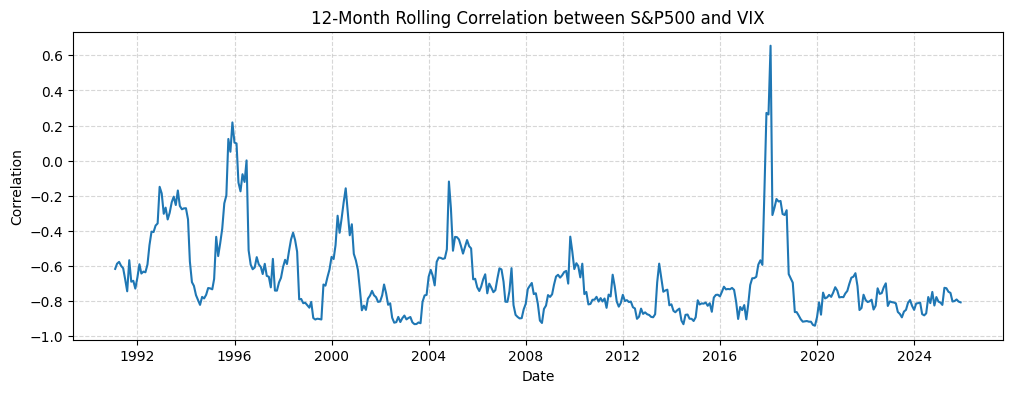

In [24]:
# Rolling correlation graph (12 months)
rolling_corr = data['SP500'].pct_change().rolling(12).corr(data['VIX'].pct_change())
plt.figure(figsize=(12,4))
plt.plot(rolling_corr)
plt.title('12-Month Rolling Correlation between S&P500 and VIX')
plt.xlabel('Date')
plt.ylabel('Correlation')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# The rolling 12-month correlation between the S&P500 and the VIX illustrates the typical inverse relationship
# between equity markets and market volatility. Negative values indicate that when the S&P500 rises, the VIX
# generally falls, reflecting lower perceived risk and market calm. Strongly negative periods, such as around
# 2003–2004, 2009, 2014, and 2020, correspond to episodes of market stress or rapid recoveries, where VIX
# spikes sharply when the market drops. Positive or near-zero correlations, observed in periods like 1996
# or 2018, reflect calmer market phases or temporary deviations from the usual inverse relationship.
# Overall, this rolling correlation confirms that the VIX acts as a fear gauge, moving opposite to
# the S&P500 in most market conditions.